# Практическая работа №4
# "Decision Tree/Random Forest & Optuna/GridSearch"



> @Гришина Ксения, 23.Б16-мм



## 📒 Полный текст задания
(из файла с дз, дублирую для удобства)

> Практическая работа № 4

> Ваша задача будет использовать DT – деревья решений, RF – случайный лес на данных, которые Вы выбрали.
> 1. Теоретическая справка: цель работы, задачи работы, используемые алгоритмы – необходимо небольшое описание алгоритмов.
> 2. Обработать данные (взять 1 лабораторную работу).
> 3. Использовать Decision Tree.
> 4. Использовать Random Forest.
> 5. Основные метрики качества проверки.
> 6. Использовать Optuna для подбора гиперпараметров.
> 7. Построить график tree_plot для деревьев решений и случайного леса.
> 8. Необходимо сравнить результаты алгоритмов между собой, а также без и с использованием Optuna.
> 9. Опционально: сравнить с GridSearch (доп 2 балла).


> Работа должна представлять собой ноутбук в GoogleCollab или Kagle (ссылка), оставленный комментарием напротив Вашей фамилии и даты выдачи работ.

> Замечание: если будет использован GPT (как копипаст), то работа не будет засчитана. Если Вы предоставляете работу с использованием GPT - кода и это вычисляется, но это не полностью копипаст, то будет снижено 50% баллов. GPT можно использовать как источник информации, но это не должно быть скопировано и неосмысленно отправлено на проверку.


> ДД данной работы: 27.10.2025 до 23:59


## 1 Теоретическая справка

**Цель работы** -  Использовать методы деревьев решений и случайного леса к данным о продаже видеоигр.

**Задачи работы:**

- Задача регрессии на признаке `Global_Sales_log`

1. Использовать Decision Tree

2. Использовать Random Forest
- Использовать Optuna
- Доп. Сравнить с GridSearch

**Используемые алгоритмы**:

*   Decision Tree (DT)
*   Random Forest (RF)

> Небольшое описание алгоритмов:

**1. Decision Tree**

> Суть: Алгоритм разбивает данные на группы на основе последовательности условий.

> Принцип работы: Отвечает на вопрос «Если <условие 1>, то <результат 1>».

> Структура:
> - Корень: Начальный вопрос или условие.
> - Ветви (узлы): Варианты ответов или дальнейшие условия.
> - Листья: Конечные решения или прогнозы, которые не имеют дальнейших ответвлений.


**2. Random Forest**

> Ансамбль деревьев: Вместо одного дерева решений строится большое их количество.

> Случайная выборка данных: Каждое дерево обучается на своей случайной подвыборке данных, полученной методом бутстрэпа (тут выборка с возвращением).

> Случайный выбор признаков: При разделении узла в каждом дереве рассматривается только случайное подмножество признаков.

> Для окончательного прогноза результаты всех деревьев объединяются, например:

> - Классификация: Выбирается наиболее популярный ответ (голосование большинством).
> - Регрессия: Вычисляется среднее значение предсказаний.



## 2 Обарботка данных

### Повтор практической работы №1

#### 1 Теоретическая справка

Для поиска своего набора данных воспользовалась поиском в [kaggle](https://www.kaggle.com/datasets/ibriiee/video-games-sales-dataset-2022-updated-extra-feat). Выбрала такой датасет о продажах видеоигр
(https://www.kaggle.com/datasets/ibriiee/video-games-sales-dataset-2022-updated-extra-feat)

На kaggle дали такое описание данным:



> Этот набор данных предоставляет актуальную информацию о продажах и популярности различных видеоигр по всему миру. Данные включают название, платформу, год выпуска, жанр, издателя и данные о продажах в Северной Америке, Европе, Японии и других регионах. Он также содержит оценки и рейтинги критиков и пользователей, включая средний рейтинг критиков, количество просмотренных игр, средний рейтинг пользователей, количество просмотренных игр, разработчика и рейтинг. Этот всеобъемлющий и важный набор данных предоставляет ценную информацию о мировом рынке видеоигр и является незаменимым инструментом для геймеров, профессионалов отрасли и исследователей рынка.



Записей: 16719.

**Признаки**(16 шт):
| Название колонки | Описание |
|------------------|----------|
| Name             | Название видеоигры |
| Platform         | Платформа, на которой была выпущена игра (PlayStation, Xbox, Nintendo и др.) |
| Year of Release  | Год выпуска игры |
| Genre            | Жанр видеоигры (экшен, приключения, спорт и др.) |
| Publisher        | Компания, выпустившая игру |
| NA Sales         | Продажи игры в Северной Америке (в млн USD) |
| EU Sales         | Продажи игры в Европе (в млн USD) |
| JP Sales         | Продажи игры в Японии (в млн USD) |
| Other Sales      | Продажи игры в других регионах (в млн USD) |
| Global Sales     | Общие мировые продажи игры (в млн USD) |
| Critic Score     | Средняя оценка игры от профессиональных критиков (0-100)|
| Critic Count     | Количество критиков, оценивших игру |
| User Score       | Средняя оценка игры от пользователей (0-10)|
| User Count       | Количество пользователей, оценивших игру |
| Developer        | Компания, разработавшая игру |
| Rating           | Возрастной рейтинг игры (ESRB, PEGI и др.) |


На этих данных можно выполнять **задачи**:
- первичный анализ данных (есть пропуски и некорректные типы данных)
- регрессии (наиболее естественная, предсказать Global_Sales)
- классификации (например, по рейтингу или платформе)
- кластеризации (группировать схожие игры)

**Задача на эту работу** - первичный анализ данных.
по содержанию ноутбука будет видно, какие шаги для этого потребовалось выполнить.

#### 2 Датасет

- Датасет индивидуален, был привязан ко мне комментарием в табличке курса

Есть несколько способов подгрузить данные в colab - через `mount` и директорию в google Drive чтобы он подгружался при каждой сессии, через kagglehub и т.д. Я воспользуюсь наиболее простым вариантом - загружу скачанный `csv`-файл в Файлы collab'а, но надо держать в уме что при следующих сессиях использования ноутбука есть шанс его "исчезновения" и надо будет вновь его туда добавить.

##### ∀ Импорты

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 7.6 MB/s eta 0:00:00


In [2]:
import os
from google.colab import drive
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import optuna
from sklearn.model_selection import cross_val_score

from sklearn.tree import plot_tree

from sklearn.model_selection import GridSearchCV


Считаем скачанный датасет

In [3]:
# 1. Добавлять напрямую, так делала в работе №1
# data = pd.read_csv('Video_Games.csv')

# 2. через mount. Это удобнее, так делаю в работе №2
# Соединяем Google Drive к Collab
gdrive_dir = '/content/drive/'
drive.mount(gdrive_dir, force_remount = True)

# Считываем датасет
data = pd.read_csv('/content/drive/MyDrive/ML-SPbU-HW/Video_Games.csv')

Mounted at /content/drive/


Проверим корректность считывания файла и попробуем посмотреть первые записи.

In [4]:
data.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


Все успешно подгрузилось.
- Заметим, что в данных **есть пропуски, как количественые, так и категориальные признаки**

Также, сразу узнаем основную информацию о датафрейме "по факту"

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


- Видим, что **есть неправильные типы данных** (многочисленные `object`-ы, `'Year_of_Release'` типа `float`)

**Вывод**: датасет согласуется с требованиями (не самый чистый).

#### 3 Обработка пропусков

из инфо выше видно, что у двух записей не хватает названия игры. можно предположить, что данные там некорректно собирались, и по логике их можно удалить.

In [6]:
# Удаляем строки, где Name пустое
data = data.dropna(subset=['Name'])

Заполним медианой год выпуска

In [7]:
# Числовые признаки заполним медианой (устойчива к выбросам)
data['Year_of_Release'] = data['Year_of_Release'].fillna(data['Year_of_Release'].median())

Заполним модой издателя

In [8]:
# Категориальные признаки заполним модой
data['Publisher'] = data['Publisher'].fillna(data['Publisher'].mode()[0])

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.2+ MB


для признаков, связанных с оценками очень много пропусков (~8к). удалив их мы потеряем половину датасета, а заполнив медианой придется учитывать, что мы могли исказить исходное распределение.



In [10]:
data['Critic_Score'].unique()

array([76., nan, 82., 80., 89., 58., 87., 91., 61., 97., 95., 77., 88.,
       83., 94., 93., 85., 86., 98., 96., 90., 84., 73., 74., 78., 92.,
       71., 72., 68., 62., 49., 67., 81., 66., 56., 79., 70., 59., 64.,
       75., 60., 63., 69., 50., 25., 42., 44., 55., 48., 57., 29., 47.,
       65., 54., 20., 53., 37., 38., 33., 52., 30., 32., 43., 45., 51.,
       40., 46., 39., 34., 35., 41., 36., 28., 31., 27., 26., 19., 23.,
       24., 21., 17., 22., 13.])

In [11]:
# Числовые признаки заполним медианой (устойчива к выбросам)
data['Critic_Score'] = data['Critic_Score'].fillna(data['Critic_Score'].median())
data['Critic_Count'] = data['Critic_Count'].fillna(data['Critic_Count'].median())

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     16717 non-null  float64
 11  Critic_Count     16717 non-null  float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.2+ MB


In [13]:
# при попытке заполнить пропуски вышла ошибка, посмотрим какие значения принимает этот признак
data['User_Score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [14]:
tbd_count = (data['User_Score'] == 'tbd').sum()
print(f"Количество 'tbd': {tbd_count}")

Количество 'tbd': 2425


In [15]:
# Преобразуем в числа, нечисловые значения станут NaN
data['User_Score'] = pd.to_numeric(data['User_Score'], errors='coerce')
# Заполним их медианой
data['User_Score'] = data['User_Score'].fillna(data['User_Score'].median())

# Проверка
data['User_Score'].unique()

array([8. , 7.5, 8.3, 8.5, 6.6, 8.4, 8.6, 7.7, 6.3, 7.4, 8.2, 9. , 7.9,
       8.1, 8.7, 7.1, 3.4, 5.3, 4.8, 3.2, 8.9, 6.4, 7.8, 2.6, 7.2, 9.2,
       7. , 7.3, 4.3, 7.6, 5.7, 5. , 9.1, 6.5, 8.8, 6.9, 9.4, 6.8, 6.1,
       6.7, 5.4, 4. , 4.9, 4.5, 9.3, 6.2, 4.2, 6. , 3.7, 4.1, 5.8, 5.6,
       5.5, 4.4, 4.6, 5.9, 3.9, 3.1, 2.9, 5.2, 3.3, 4.7, 5.1, 3.5, 2.5,
       1.9, 3. , 2.7, 2.2, 2. , 9.5, 2.1, 3.6, 2.8, 1.8, 3.8, 0. , 1.6,
       9.6, 2.4, 1.7, 1.1, 0.3, 1.5, 0.7, 1.2, 2.3, 0.5, 1.3, 0.2, 0.6,
       1.4, 0.9, 1. , 9.7])

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     16717 non-null  float64
 11  Critic_Count     16717 non-null  float64
 12  User_Score       16717 non-null  float64
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(10), object(6)
memory usage: 2.2+ MB


In [17]:
data['User_Score'] = data['User_Score'].fillna(data['User_Score'].median())
data['User_Count'] = data['User_Count'].fillna(data['User_Count'].median())

Так как пропуски в этих признаках есть в почти половине записей, заполнять стат методами мы можем изменить распределение. Создадим новую категорию, чтобы не искажать исходные данные.

In [18]:
# заполняем пропуски в рейтинге значением "неизвестно"
data["Rating"] = data["Rating"].fillna("Unknown")
data["Developer"] = data["Developer"].fillna("Unknown")

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     16717 non-null  float64
 11  Critic_Count     16717 non-null  float64
 12  User_Score       16717 non-null  float64
 13  User_Count       16717 non-null  float64
 14  Developer        16717 non-null  object 
 15  Rating           16717 non-null  object 
dtypes: float64(10), object(6)
memory usage: 2.2+ MB


**Вывод**: заполнили пропуски, стараясь сохранить реальность данных и применимость к основным задачам датасета

#### 4 Обработка выбросов

Для начала, было бы неплохо узнать, есть ли они вообще. Для этого посмотрим на Q3 и max в инфо или на боксплотах.

In [20]:
data.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.00000,16717.000000
mean,2006.497218,0.263255,0.145010,0.077610,0.047333,0.533462,70.010767,23.609380,7.32976,86.760364
std,5.830342,0.813475,0.503303,0.308836,0.186721,1.547956,9.776915,13.510184,1.02779,384.399216
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.00000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,71.000000,21.000000,7.50000,24.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,7.50000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,71.000000,21.000000,7.50000,24.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,9.70000,10665.000000


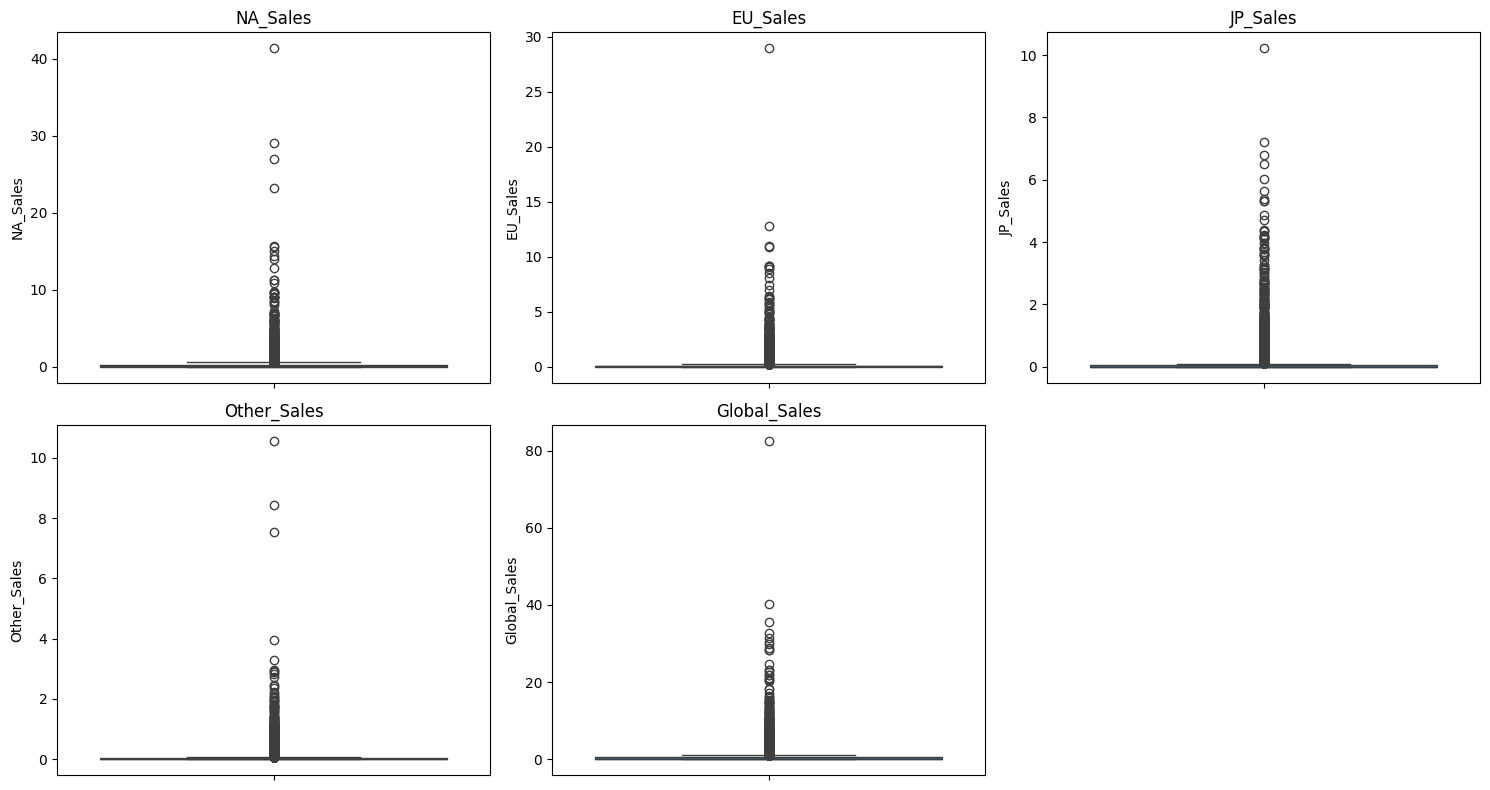

In [21]:
# Список столбцов продаж
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

plt.figure(figsize=(15, 8))

# Проходим по каждому столбцу и строим боксплот
for i, col in enumerate(sales_cols, 1):
    plt.subplot(2, 3, i)  # создаём сетку 2x3
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Выяснили, что наши данные очень асимметричны, т е что есть и очень успешные игры, с продажами сильно выше среднего, и провальные проекты. Но в основном у нас не совсем так, поэтому на них можно смотреть как на выбросы. (Зависит от задачи.)

Прологарифмировав данные мы можем избавиться от тяжелых хвостов и сделать их более симметричными.

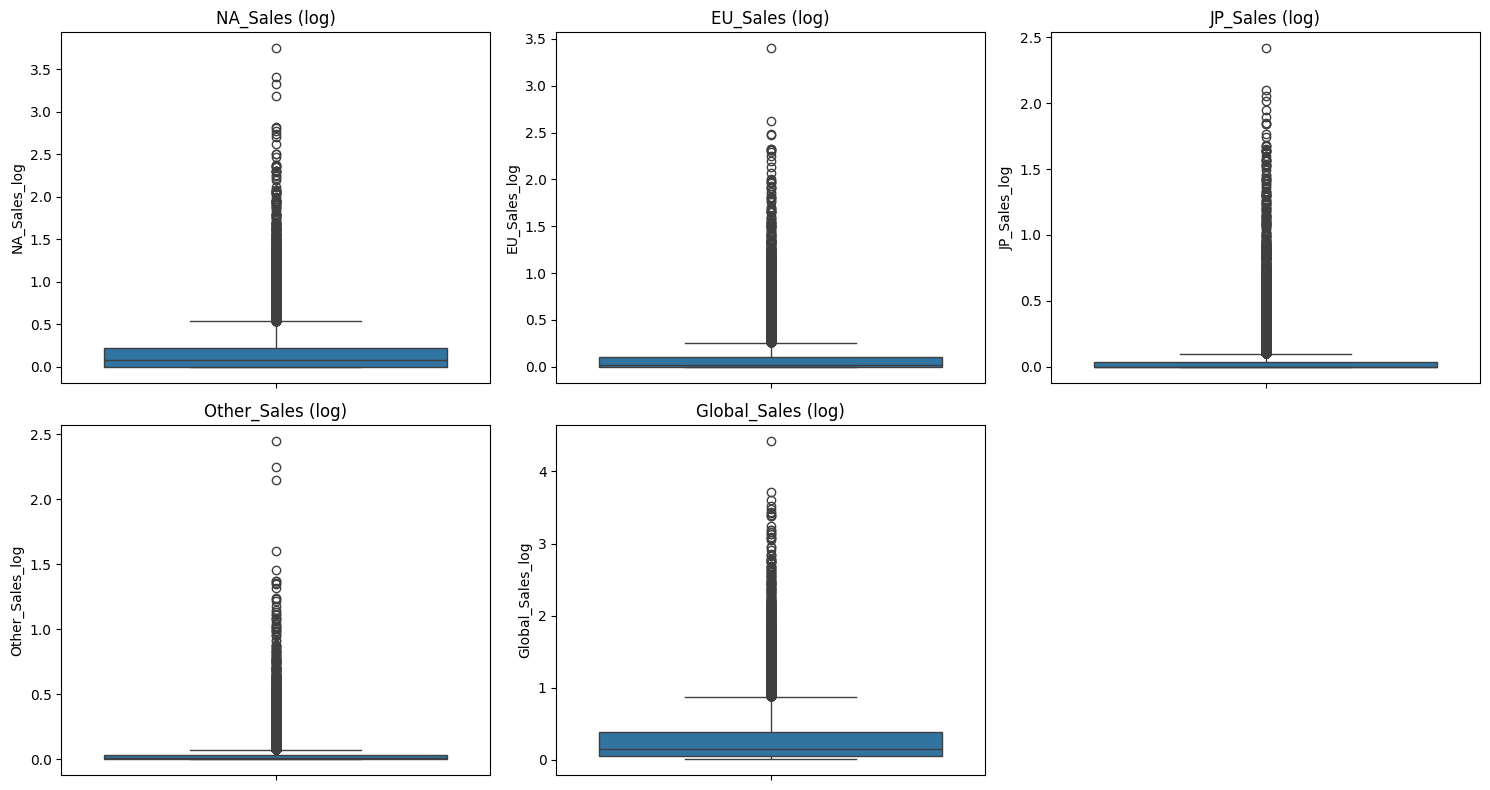

In [22]:
# создаём логарифмированные столбцы
for col in sales_cols:
    data[col + '_log'] = np.log1p(data[col])

# визуализация
plt.figure(figsize=(15, 8))
for i, col in enumerate(sales_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col + '_log'])
    plt.title(col + ' (log)')

plt.tight_layout()
plt.show()

При использовании межквартильного размаха для удаления выбросов мы потреяем большую часть данных(~6k).

In [23]:
sales_log_cols = ['NA_Sales_log', 'EU_Sales_log', 'JP_Sales_log', 'Other_Sales_log', 'Global_Sales_log']

for col in sales_log_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # оставляем только строки без выбросов
    data = data[(data[col] >= lower) & (data[col] <= upper)]

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              10671 non-null  object 
 1   Platform          10671 non-null  object 
 2   Year_of_Release   10671 non-null  float64
 3   Genre             10671 non-null  object 
 4   Publisher         10671 non-null  object 
 5   NA_Sales          10671 non-null  float64
 6   EU_Sales          10671 non-null  float64
 7   JP_Sales          10671 non-null  float64
 8   Other_Sales       10671 non-null  float64
 9   Global_Sales      10671 non-null  float64
 10  Critic_Score      10671 non-null  float64
 11  Critic_Count      10671 non-null  float64
 12  User_Score        10671 non-null  float64
 13  User_Count        10671 non-null  float64
 14  Developer         10671 non-null  object 
 15  Rating            10671 non-null  object 
 16  NA_Sales_log      10671 non-null  float64


In [25]:
# Был другой вариант: Чтобы не удалять столько записей,
# и терять хитов индустрии, можно было их обработать - подрезать
# экстремальные значения сверху и снизу на до границ IQR. Так хиты останутся,
# но их значения будут не так разбросаны. Боксплоты будут вообще без выбросов.

# я решила так не делать, так как на мой взгляд это сильно искажает
# реальную картину, но может это не так.


# # sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

# for col in sales_cols:
#     lower = data[col].quantile(0.25)
#     upper = data[col].quantile(0.75)
#     data[col] = data[col].clip(lower, upper)

# print(data[sales_cols].describe())

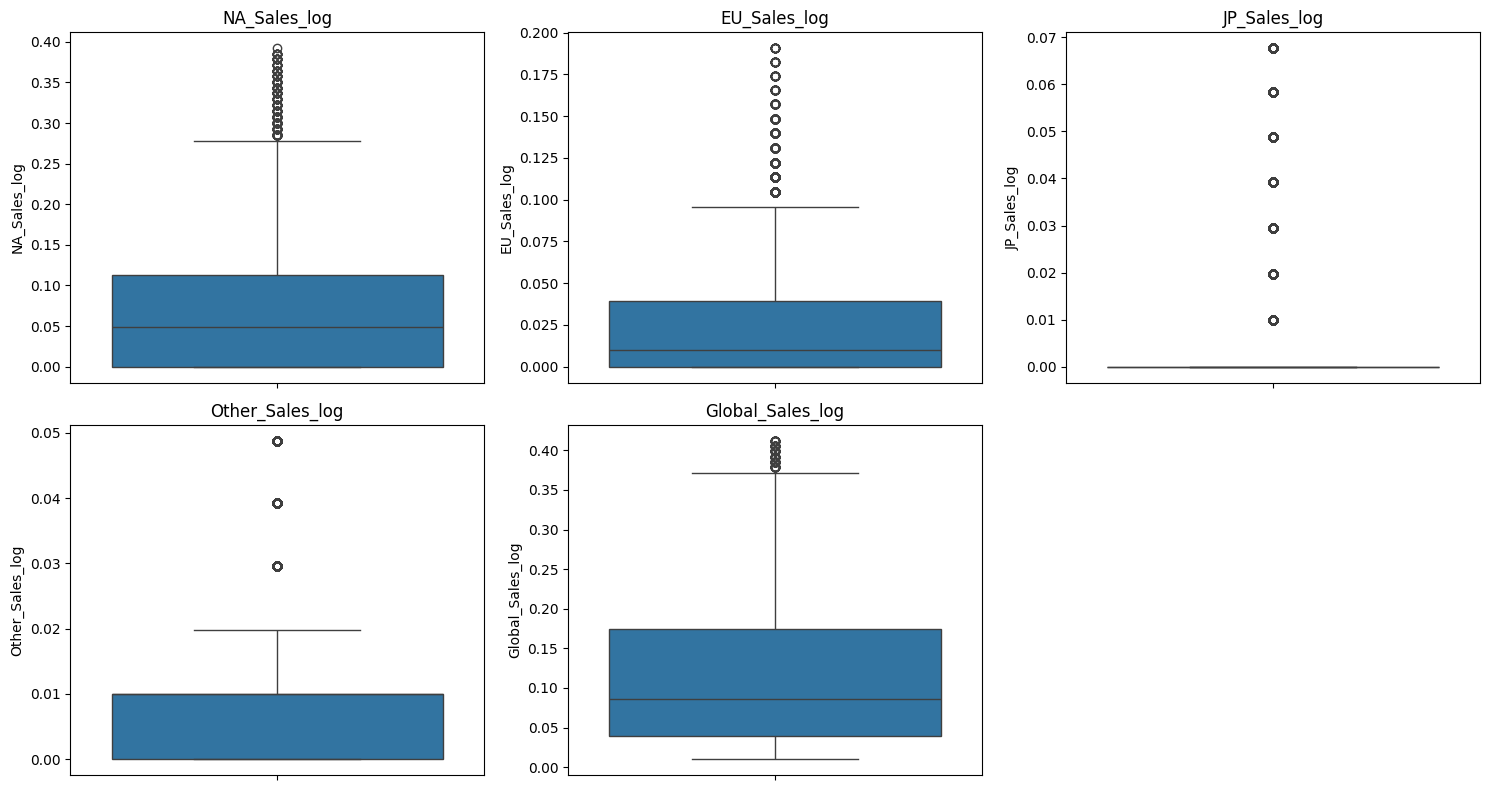

In [26]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(sales_log_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Ситуация с выбросами стала лучше.
Хотя точки выше новых "усов" все еще есть, их гораздо меньше чем было изначально.

**Вывод:** с помощью ящика с усами обнаружили выбросы в продажах, удалили их с помощью межквартильного размаха.

#### 5 Обработка неправильных типов данных

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              10671 non-null  object 
 1   Platform          10671 non-null  object 
 2   Year_of_Release   10671 non-null  float64
 3   Genre             10671 non-null  object 
 4   Publisher         10671 non-null  object 
 5   NA_Sales          10671 non-null  float64
 6   EU_Sales          10671 non-null  float64
 7   JP_Sales          10671 non-null  float64
 8   Other_Sales       10671 non-null  float64
 9   Global_Sales      10671 non-null  float64
 10  Critic_Score      10671 non-null  float64
 11  Critic_Count      10671 non-null  float64
 12  User_Score        10671 non-null  float64
 13  User_Count        10671 non-null  float64
 14  Developer         10671 non-null  object 
 15  Rating            10671 non-null  object 
 16  NA_Sales_log      10671 non-null  float64


In [28]:
# object -> int (можно в datetime)
data['Year_of_Release'] = data['Year_of_Release'].astype(int)

In [29]:
# float -> int (там только целые значения)
int_cols = ['Critic_Score', 'Critic_Count', 'User_Score', 'User_Count']

for col in int_cols:
    data[col] = data[col].astype(int)

In [30]:
# object -> категориальные
cat_cols = [ 'Platform', 'Genre', 'Rating',  'Name', 'Publisher', 'Developer']

for col in cat_cols:
    data[col] = data[col].astype('category')

In [31]:
print(data.info())

data.head(1)

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Name              10671 non-null  category
 1   Platform          10671 non-null  category
 2   Year_of_Release   10671 non-null  int64   
 3   Genre             10671 non-null  category
 4   Publisher         10671 non-null  category
 5   NA_Sales          10671 non-null  float64 
 6   EU_Sales          10671 non-null  float64 
 7   JP_Sales          10671 non-null  float64 
 8   Other_Sales       10671 non-null  float64 
 9   Global_Sales      10671 non-null  float64 
 10  Critic_Score      10671 non-null  int64   
 11  Critic_Count      10671 non-null  int64   
 12  User_Score        10671 non-null  int64   
 13  User_Count        10671 non-null  int64   
 14  Developer         10671 non-null  category
 15  Rating            10671 non-null  category
 16  NA_Sales_log      10671 

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,Critic_Count,User_Score,User_Count,Developer,Rating,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,35,5,22,Blitz Games Studios,E,0.277632,0.139762,0.0,0.039221,0.41211


**Вывод**: привели все признаки к корректным типам:

- Числовые признаки (`Year_of_Release`, `User_Score`, `Critic_Score`, `Critic_Count`, `User_Count`, `Sales`'ы) были приведены к `float` или `int`.

- Качественные признаки (`Platform`, `Genre`, `Publisher`, `Developer`, `Rating`, `Name`) были приведены к типу `category`.

После этой обработки все данные стали однородными, нет типа `object`.

#### 6 Преобразование качественных признаков

Этих категорий, которые представлены ниже, не так много, как в остальных качественнных признаках


In [32]:
print(data.Platform.unique())
print(data.Genre.unique())
print(data.Rating.unique())

['X360', '2600', 'DS', 'GC', 'PS', ..., '3DO', 'GG', 'WS', 'PCFX', 'TG16']
Length: 31
Categories (31, object): ['2600', '3DO', '3DS', 'DC', ..., 'WiiU', 'X360', 'XB', 'XOne']
['Action', 'Sports', 'Role-Playing', 'Puzzle', 'Adventure', ..., 'Fighting', 'Shooter', 'Racing', 'Simulation', 'Strategy']
Length: 12
Categories (12, object): ['Action', 'Adventure', 'Fighting', 'Misc', ..., 'Shooter', 'Simulation',
                          'Sports', 'Strategy']
['E', 'Unknown', 'E10+', 'T', 'M', 'EC', 'RP', 'K-A']
Categories (8, object): ['E', 'E10+', 'EC', 'K-A', 'M', 'RP', 'T', 'Unknown']


их можно закодировать.


Если спользовать `One Hot Encoding`, то это приведет к раздуванию датасета.

Используем `LabelEncoder`, в нем каждой категории присваивается число (напр `PS3 - 1, Wii - 2, PC - …`)

In [33]:
le = LabelEncoder()
for col in ['Platform', 'Genre', 'Rating']:
    data[col + '_code'] = le.fit_transform(data[col])
data.head(2)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,Developer,Rating,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,Blitz Games Studios,E,0.277632,0.139762,0.0,0.039221,0.41211,28,0,0
3883,Fishing Derby,2600,2007,Sports,Activision,0.48,0.03,0.0,0.01,0.51,...,Unknown,Unknown,0.392042,0.029559,0.0,0.009950,0.41211,0,10,7


Однако качественные признаки `'Name'`, `'Publisher'`, `'Developer'` остались незакодированными.

(`Name` можно было бы и удалить вовсе, так как в моделях вероятнее всего этот признак не будем использовать, но пока пусть остается.)

Так как их уникальных значений очень много, можно закодировать их через `frequency encoder` (не значениями `0,...,k` а их частотой появления в дф, это дает меньше аффекта для линейных моделей, которые могуть считать новые признаки упорядоченными)



In [34]:
for col in ['Publisher', 'Developer', 'Name']:
    freq = data[col].value_counts() / len(data)
    data[col + '_freq_code'] = data[col].map(freq)
data.head(2)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code,Publisher_freq_code,Developer_freq_code,Name_freq_code
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,0.139762,0.0,0.039221,0.41211,28,0,0,0.011714,0.000562,0.000187
3883,Fishing Derby,2600,2007,Sports,Activision,0.48,0.03,0.0,0.01,0.51,...,0.029559,0.0,0.009950,0.41211,0,10,7,0.059882,0.375129,0.000094


**Вывод**: закодировали качественные признаки методами `Label&Frequency Encoder`

#### ❓Удалим старые признаки


Так как мы преобразовали исходные признаки (логарифмировали, закодировали категориальные), первоначальные признаки можно убрать из датасета, ибо они по сути дублируют информацию и все равно будут сильно коррелировать с новыми признаками. Однако потом их нельзя будет использовать для визуализации.

In [35]:
data.drop(columns=['Name', 'Platform', 'Genre', 'Publisher','NA_Sales',
                   'EU_Sales','JP_Sales','Other_Sales','Global_Sales','Developer',
                   'Rating'], inplace=True)

#### 7 Разделение выборки (на тренировочную, тестовую, валидационную)

Разделим выборку в соотношении `60/20/20`




In [36]:
# X — все признаки,
# y — целевая переменная (например, Global_Sales_log)
# При интерпертации результатов надо будет вернуться (y_pred_real = np.expm1(y_pred_log))
X = data.drop(columns=['Global_Sales_log'])
y = data['Global_Sales_log']

# сначала выделяем тренировочную 60% и временную 40% (для валидации и теста)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# затем делим оставшиеся 40% пополам: 20% валидация, 20% тест
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# проверим размеры выборок
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Train: (6402, 15) Validation: (2134, 15) Test: (2135, 15)


или в процентах:

In [37]:
n_total = len(data)
print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/n_total*100:.1f}%)")
print(f"Validation: {X_val.shape[0]} ({X_val.shape[0]/n_total*100:.1f}%)")
print(f"Test: {X_test.shape[0]} ({X_test.shape[0]/n_total*100:.1f}%)")

Train: 6402 (60.0%)
Validation: 2134 (20.0%)
Test: 2135 (20.0%)


как и ожидалось.

**Вывод**: При `random_state=42` разделили выборку на три части:

- Тренировочная выборка (`X_train, y_train`) — 60% данных (используется для обучения моделей)

- Валидационная выборка (`X_val, y_val`)— 20% данных (используется для подбора гиперпараметров и контроля переобучения)

- Тестовая выборка (`X_test, y_test`)— 20% данных (используется для финальной оценки качества модели)

#### 8 Стандартизация данных

Цель — преобразовать исходный набор в новый со средним значением равным 0 и стандартным отклонением равным 1.

Стандартизация нужна, чтобы все числовые признаки имели одинаковый масштаб. Это важно для некоторых чувствительных к нему моделей.

У нас, например, оценки критиков(0-100) и игроков(0-10) меняются в разных масштабах.

Стандартизуем числовые признаки.

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_of_Release      10671 non-null  int64  
 1   Critic_Score         10671 non-null  int64  
 2   Critic_Count         10671 non-null  int64  
 3   User_Score           10671 non-null  int64  
 4   User_Count           10671 non-null  int64  
 5   NA_Sales_log         10671 non-null  float64
 6   EU_Sales_log         10671 non-null  float64
 7   JP_Sales_log         10671 non-null  float64
 8   Other_Sales_log      10671 non-null  float64
 9   Global_Sales_log     10671 non-null  float64
 10  Platform_code        10671 non-null  int64  
 11  Genre_code           10671 non-null  int64  
 12  Rating_code          10671 non-null  int64  
 13  Publisher_freq_code  10671 non-null  float64
 14  Developer_freq_code  10671 non-null  float64
 15  Name_freq_code       10671 non-null  f

In [39]:
scaler = StandardScaler()

# выбираем признаки для стандартизации
num_features = [
    'Year_of_Release',
    'Critic_Score',
    'Critic_Count',
    'User_Score',
    'User_Count',
    'NA_Sales_log',
    'EU_Sales_log',
    'Other_Sales_log'
]

# fit на train
scaler.fit(X_train[num_features])

# трансформируем train, test, val
X_train[num_features] = scaler.transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])
X_val[num_features] = scaler.transform(X_val[num_features])

**Вывод**: стандартизировали числовые признаки (`'Year_of_Release','Critic_Score','Critic_Count',
'User_Score',
'User_Count',
'NA_Sales_log',
'EU_Sales_log',
'Other_Sales_log'`) с помощью `StandardScaler`

#### 9 Визуализация

Построим различные графики для визуализации наших данных.

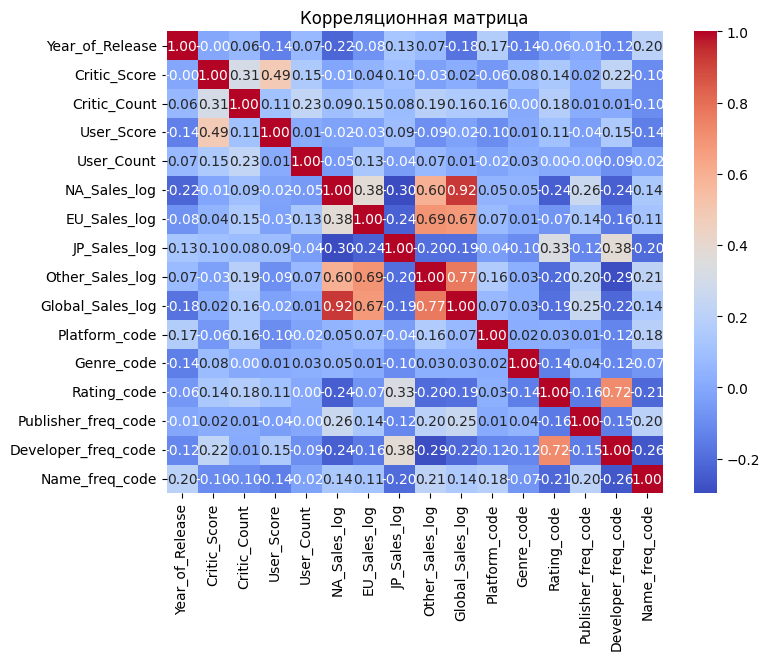

In [40]:
# 1.Корреляционная матрица
external_corr = data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(external_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляционная матрица')
plt.show()

In [41]:
# 2.Диаграмма рассеяния
# sns.pairplot(data=data)

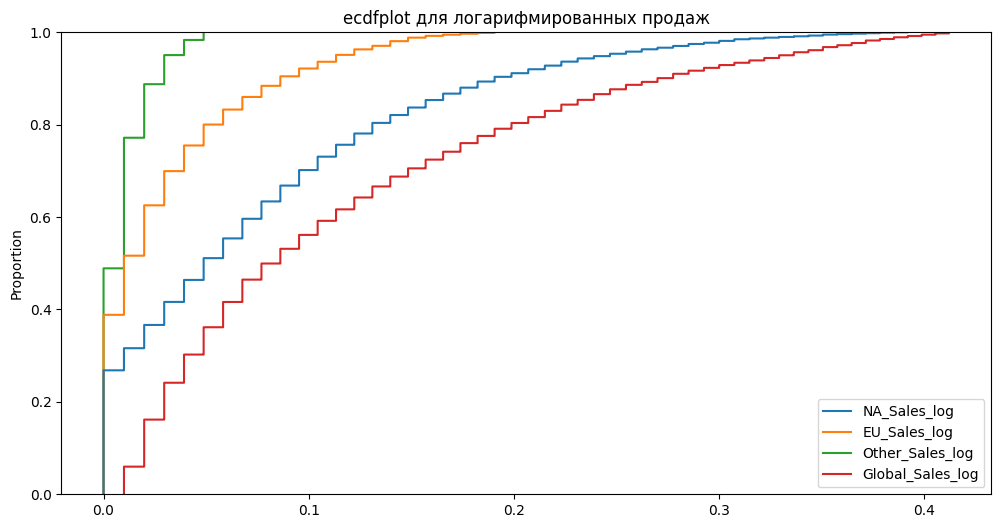

In [42]:
# 3. ecdfplot по регионам продаж
plt.figure(figsize=(12, 6))
sns.ecdfplot(data=data[['NA_Sales_log', 'EU_Sales_log', 'Other_Sales_log', 'Global_Sales_log']])
plt.title("ecdfplot для логарифмированных продаж")
plt.show()

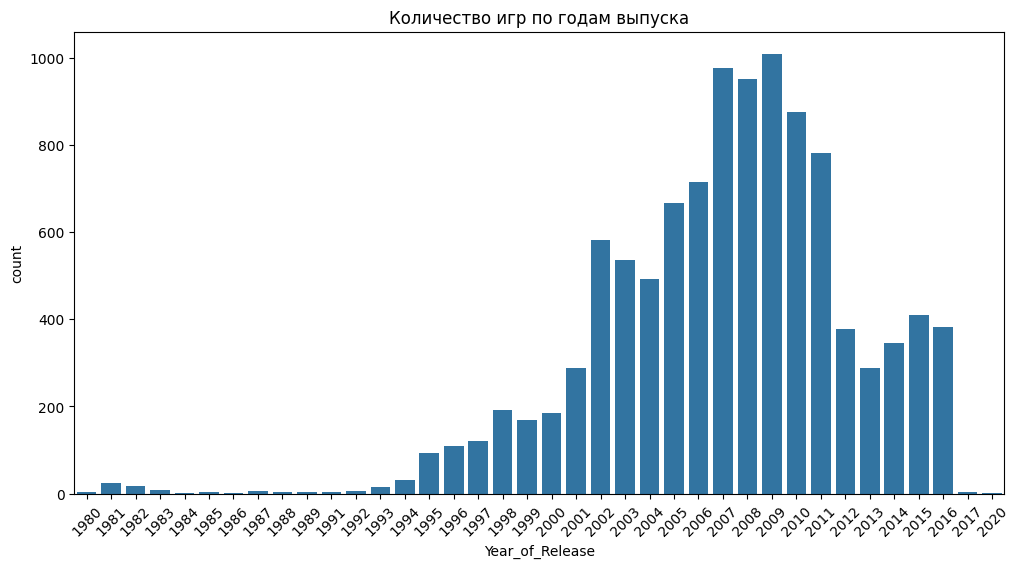

In [43]:
# 4. Тренд по годам
plt.figure(figsize=(12, 6))
sns.countplot(x="Year_of_Release", data=data)
plt.xticks(rotation=45)
plt.title("Количество игр по годам выпуска")
plt.show()

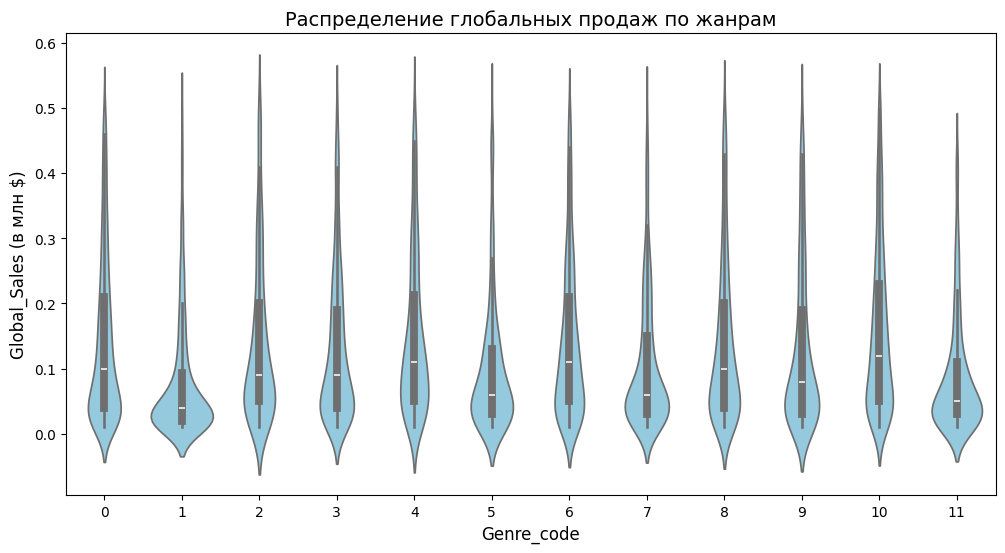

In [44]:
# 5. Скрипичная диаграмма
plt.figure(figsize=(12, 6))
sns.violinplot(
    x="Genre_code",
    y=np.expm1(data["Global_Sales_log"]),
    data=data,
    inner="box",
    color="skyblue"
)

plt.title("Распределение глобальных продаж по жанрам", fontsize=14)
plt.xlabel("Genre_code", fontsize=12)
plt.ylabel("Global_Sales (в млн $)", fontsize=12)
plt.show()

**Вывод**: визуализация позволяет наглядно увидеть распределение признаков, выявить выбросы, зависимости

#### 10 Методы описания данных

Используем ≥ 8 разных методов описания данных

In [45]:
print("1. Размерность датасета:", data.shape)

print("\n2.Информация о данных:")
display(data.info())

print("\n3.Первые 5 строк:")
display(data.head())

print("\n4.Последние 5 строк:")
display(data.tail())

print("\n5.Основная статистика (числовые признаки):")
display(data.describe())

print("\n6.Количество пропусков:")
display(data.isnull().sum())

print("\n7.Количество уникальных значений:")
display(data.nunique())

print("\n8.Корреляция:")
display(data.corr())

print("\n9.оценка использования памяти:")
display(data.memory_usage(deep=True))

1. Размерность датасета: (10671, 16)

2.Информация о данных:
<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_of_Release      10671 non-null  int64  
 1   Critic_Score         10671 non-null  int64  
 2   Critic_Count         10671 non-null  int64  
 3   User_Score           10671 non-null  int64  
 4   User_Count           10671 non-null  int64  
 5   NA_Sales_log         10671 non-null  float64
 6   EU_Sales_log         10671 non-null  float64
 7   JP_Sales_log         10671 non-null  float64
 8   Other_Sales_log      10671 non-null  float64
 9   Global_Sales_log     10671 non-null  float64
 10  Platform_code        10671 non-null  int64  
 11  Genre_code           10671 non-null  int64  
 12  Rating_code          10671 non-null  int64  
 13  Publisher_freq_code  10671 non-null  float64
 14  Developer_freq_code  10671 

None


3.Первые 5 строк:


,Year_of_Release,Critic_Score,Critic_Count,User_Score,User_Count,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code,Publisher_freq_code,Developer_freq_code,Name_freq_code
3882,2012,59,35,5,22,0.277632,0.139762,0.0,0.039221,0.41211,28,0,0,0.011714,0.000562,0.000187
3883,2007,71,21,7,24,0.392042,0.029559,0.0,0.009950,0.41211,0,10,7,0.059882,0.375129,0.000094
3885,2008,70,26,7,14,0.307485,0.104360,0.0,0.039221,0.41211,4,7,1,0.011714,0.000094,0.000094
3889,2003,94,19,7,17,0.336472,0.095310,0.0,0.009950,0.41211,7,10,0,0.062974,0.003655,0.000187
3893,1997,71,21,7,24,0.246860,0.173953,0.0,0.029559,0.41211,15,10,7,0.002437,0.375129,0.000094



4.Последние 5 строк:


...

,0
Year_of_Release,38
Critic_Score,79
Critic_Count,83
User_Score,10
User_Count,444
NA_Sales_log,49
EU_Sales_log,22
JP_Sales_log,8
Other_Sales_log,6
Global_Sales_log,51



8.Корреляция:


,Year_of_Release,Critic_Score,Critic_Count,User_Score,User_Count,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code,Publisher_freq_code,Developer_freq_code,Name_freq_code
Year_of_Release,1.000000,-0.004974,0.063585,-0.135394,0.072110,-0.221161,-0.082508,0.126732,0.074327,-0.175783,0.172315,-0.140934,-0.061649,-0.005263,-0.115052,0.199811
Critic_Score,-0.004974,1.000000,0.306266,0.486239,0.149531,-0.012382,0.042722,0.101755,-0.031612,0.017338,-0.062463,0.078423,0.141035,0.018273,0.221947,-0.100208
Critic_Count,0.063585,0.306266,1.000000,0.105460,0.230355,0.093304,0.154477,0.081121,0.186785,0.155537,0.158673,0.004493,0.177142,0.012780,0.007217,-0.096815
User_Score,-0.135394,0.486239,0.105460,1.000000,0.009505,-0.022961,-0.026064,0.085784,-0.092006,-0.024118,-0.098656,0.009247,0.105482,-0.038410,0.153582,-0.141821
User_Count,0.072110,0.149531,0.230355,0.009505,1.000000,-0.050299,0.134523,-0.038972,0.069175,0.010473,-0.016537,0.025721,0.004715,-0.000324,-0.093155,-0.022207
NA_Sales_log,-0.221161,-0.012382,0.093304,-0.022961,-0.050299,1.000000,0.380489,-0.297405,0.595894,0.924402,0.046000,0.045636,-0.242382,0.260914,-0.239551,0.143025
EU_Sales_log,-0.082508,0.042722,0.154477,-0.026064,0.134523,0.380489,1.000000,-0.235728,0.691716,0.671231,0.074843,0.011314,-0.073073,0.135878,-0.156566,0.113925
JP_Sales_log,0.126732,0.101755,0.081121,0.085784,-0.038972,-0.297405,-0.235728,1.000000,-0.195593,-0.187165,-0.039114,-0.101471,0.326440,-0.119381,0.377385,-0.204852
Other_Sales_log,0.074327,-0.031612,0.186785,-0.092006,0.069175,0.595894,0.691716,-0.195593,1.000000,0.768229,0.159372,0.030792,-0.202415,0.201848,-0.288729,0.211167
Global_Sales_log,-0.175783,0.017338,0.155537,-0.024118,0.010473,0.924402,0.671231,-0.187165,0.768229,1.000000,0.070935,0.029305,-0.187093,0.254887,-0.215582,0.144024



9.оценка использования памяти:


,0
Index,85368
Year_of_Release,85368
Critic_Score,85368
Critic_Count,85368
User_Score,85368
User_Count,85368
NA_Sales_log,85368
EU_Sales_log,85368
JP_Sales_log,85368
Other_Sales_log,85368


**Вывод**: Для первичного анализа датасета использованы методы (`shape`, `info`, `head`, `tail`, `describe`, `isnull`, `nunique`, `corr`, `memory_usage`). Эти функции позволяют быстро получить ключевую информацию о структуре данных, наличии пропусков, распределении признаков, связях между переменными и размере датасета.

#### ⇒ Главный вывод по работе №1

**Главный вывод**: проведен первичный анализ, обработка пропусков и выбросов, стандартизация и кодирование признаков. подготовили датасет `Video_Games.csv` к моделированию. Данные корректны и подходят для дальнейшего построения моделей машинного обучения.

## 3 `Decision Tree` (DT)

Как было сказано в теор справке -- будем использовать алгоритмы на задаче регрессии (на признаке `Global_Sales_log`).

In [46]:
# data.info()

In [47]:
# Создаём модель
dt = DecisionTreeRegressor(
    max_depth=5,        # ограничиение глубины дерева
    random_state=42       # сид
)

# Обучаем модель
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [48]:
y_pred_dt = dt.predict(X_test)

## 4 `Random Forest`, (RF)

In [49]:
# Создаём модель
rf = RandomForestRegressor(
    n_estimators=10,   # количество деревьев
    max_depth=5,       # ограничение глубины
    random_state=42,    # сид
    n_jobs=-1           # используем все ядра процессора
)

# Обучаем модель
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=10, n_jobs=-1, random_state=42)

In [50]:
y_pred_rf = rf.predict(X_test)


## 5 Основные метрики качества

### DT

In [51]:
# Метрики для DT
mse_dt = mean_squared_error(y_test, y_pred_dt)
print(f"MSE (DT): {mse_dt:.3f}")

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
print(f"RMSE (DT): {rmse_dt:.3f}")

r2_dt = r2_score(y_test, y_pred_dt)
print(f"R^2 (DT): {r2_dt:.3f}")

mae_dt = mean_absolute_error(y_test, y_pred_dt)
print(f"MAE (DT): {mae_dt:.3f}")

mape_dt = np.mean(np.abs((y_test - y_pred_dt) / y_test)) * 100
print(f"MAPE (DT): {mape_dt:.2f}%")

MSE (DT): 0.000
RMSE (DT): 0.019
R^2 (DT): 0.966
MAE (DT): 0.013
MAPE (DT): 22.32%


###  RF

In [52]:
# Метрики для RF
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"MSE (RF): {mse_rf:.3f}")

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"RMSE (RF): {rmse_rf:.3f}")

r2_rf = r2_score(y_test, y_pred_rf)
print(f"R^2 (RF): {r2_rf:.3f}")

mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f"MAE (RF): {mae_rf:.3f}")

mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
print(f"MAPE (RF): {mape_rf:.2f}%")

MSE (RF): 0.000
RMSE (RF): 0.014
R^2 (RF): 0.982
MAE (RF): 0.010
MAPE (RF): 21.85%


## 6 `Optuna` для подбора гиперпараметров

### DT

Определим trial для optuna:

In [53]:
def objective_dt(trial):
    # Подбираем гиперпараметры
    max_depth = trial.suggest_int("max_depth", 1, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)

    # Создаём модель с ними
    model = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    # Кросс-валидация
    scores = cross_val_score(model, X_train, y_train, cv=5, # число fold-ов
                             scoring='neg_mean_squared_error', n_jobs=-1)

    # Возвращаем RMSE
    rmse = np.sqrt(-scores.mean())
    return rmse

Создадим и запустим исследование оптуны:

In [54]:
study_dt = optuna.create_study(direction="minimize")  # минимизируем RMSE
study_dt.optimize(objective_dt, n_trials=50)             # пробуем 50 раз

[I 2025-10-23 10:23:34,189] A new study created in memory with name: no-name-abc7a8b4-34a0-4717-a2e0-5f99821d16f1
[I 2025-10-23 10:23:38,080] Trial 0 finished with value: 0.030815214327530913 and parameters: {'max_depth': 3, 'min_samples_split': 19, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.030815214327530913.
[I 2025-10-23 10:23:38,215] Trial 1 finished with value: 0.011963194421836207 and parameters: {'max_depth': 17, 'min_samples_split': 20, 'min_samples_leaf': 20}. Best is trial 1 with value: 0.011963194421836207.
[I 2025-10-23 10:23:38,339] Trial 2 finished with value: 0.012412468555964984 and parameters: {'max_depth': 7, 'min_samples_split': 14, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.011963194421836207.
[I 2025-10-23 10:23:38,482] Trial 3 finished with value: 0.011265241838031929 and parameters: {'max_depth': 19, 'min_samples_split': 9, 'min_samples_leaf': 15}. Best is trial 3 with value: 0.011265241838031929.
[I 2025-10-23 10:23:38,626] Trial 4 finishe

In [55]:
print("Лучшие параметры для DT:", study_dt.best_params)
print("Лучший RMSE для DT:", study_dt.best_value)

Лучшие параметры для DT: {'max_depth': 13, 'min_samples_split': 12, 'min_samples_leaf': 2}
Лучший RMSE для DT: 0.009533979875719576


Обучим на лучших параметрах модель:

In [56]:
best_params_dt_opt = study_dt.best_params

dt_opt = DecisionTreeRegressor(
    max_depth=best_params_dt_opt["max_depth"],
    min_samples_split=best_params_dt_opt["min_samples_split"],
    min_samples_leaf=best_params_dt_opt["min_samples_leaf"],
    random_state=42
)

dt_opt.fit(X_train, y_train)
y_pred_dt_opt = dt_opt.predict(X_test)

- метрики

In [57]:
# Метрики для DT+Optuna
rmse_dt_opt = np.sqrt(mean_squared_error(y_test, y_pred_dt_opt))
print(f"RMSE (DT+Optuna): {rmse_dt_opt:.3f}")

mse_dt_opt = mean_squared_error(y_test, y_pred_dt_opt)
print(f"MSE (DT+Optuna): {mse_dt_opt:.3f}")

r2_dt_opt = r2_score(y_test, y_pred_dt_opt)
print(f"R^2 (DT+Optuna): {r2_dt_opt:.3f}")

mae_dt_opt = mean_absolute_error(y_test, y_pred_dt_opt)
print(f"MAE (DT+Optuna): {mae_dt_opt:.3f}")

mape_dt_opt = np.mean(np.abs((y_test - y_pred_dt_opt) / y_test)) * 100
print(f"MAPE (DT+Optuna): {mape_dt_opt:.2f}%")

RMSE (DT+Optuna): 0.009
MSE (DT+Optuna): 0.000
R^2 (DT+Optuna): 0.992
MAE (DT+Optuna): 0.005
MAPE (DT+Optuna): 6.69%


###  RF

Определим trial для optuna:

In [58]:
def objective_rf(trial):
    # Подбираем гиперпараметры
    n_estimators = trial.suggest_int("n_estimators", 1, 20)
    max_depth = trial.suggest_int("max_depth", 1, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])

    # Создаём модель
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    # Кросс-валидация
    scores = cross_val_score(model, X_train, y_train, cv=5, # число fold-ов
                             scoring='neg_mean_squared_error', n_jobs=-1)

    rmse = np.sqrt(-scores.mean())
    return rmse

Создадим и запустим исследование оптуны:

In [59]:
study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=50)  # 50 пробных комбинаций

[I 2025-10-23 10:23:45,510] A new study created in memory with name: no-name-01dfac26-e556-4e3a-980e-dacf9841f227
[I 2025-10-23 10:23:45,651] Trial 0 finished with value: 0.03778521409213288 and parameters: {'n_estimators': 1, 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 13, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.03778521409213288.
[I 2025-10-23 10:23:45,880] Trial 1 finished with value: 0.022797221048025406 and parameters: {'n_estimators': 6, 'max_depth': 11, 'min_samples_split': 20, 'min_samples_leaf': 13, 'max_features': 'log2'}. Best is trial 1 with value: 0.022797221048025406.
[I 2025-10-23 10:23:46,246] Trial 2 finished with value: 0.02091156434187648 and parameters: {'n_estimators': 15, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 15, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.02091156434187648.
[I 2025-10-23 10:23:46,583] Trial 3 finished with value: 0.024589896860093465 and parameters: {'n_estimators': 13, 'max_depth'

In [60]:
print("Лучшие параметры для RF:", study_rf.best_params)
print("Лучший RMSE для RF:", study_rf.best_value)

Лучшие параметры для RF: {'n_estimators': 14, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'}
Лучший RMSE для RF: 0.014911555352955682


Обучим на лучших параметрах модель:

In [61]:
best_params = study_rf.best_params

rf_opt = RandomForestRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"],
    random_state=42,
    n_jobs=-1
)

rf_opt.fit(X_train, y_train)
y_pred_rf_opt = rf_opt.predict(X_test)

- метрики

In [62]:
# Метрики для RF+Optuna
rmse_rf_opt = np.sqrt(mean_squared_error(y_test, y_pred_rf_opt))
print(f"RMSE (RF+Optuna): {rmse_rf_opt:.3f}")

mse_rf_opt = mean_squared_error(y_test, y_pred_rf_opt)
print(f"MSE (RF+Optuna): {mse_rf_opt:.3f}")

r2_rf_opt = r2_score(y_test, y_pred_rf_opt)
print(f"R^2 (RF+Optuna): {r2_rf_opt:.3f}")

mae_rf_opt = mean_absolute_error(y_test, y_pred_rf_opt)
print(f"MAE (RF+Optuna): {mae_rf_opt:.3f}")

mape_rf_opt = np.mean(np.abs((y_test - y_pred_rf_opt) / y_test)) * 100
print(f"MAPE (RF+Optuna): {mape_rf_opt:.2f}%")

RMSE (RF+Optuna): 0.015
MSE (RF+Optuna): 0.000
R^2 (RF+Optuna): 0.979
MAE (RF+Optuna): 0.009
MAPE (RF+Optuna): 13.96%


## 7 График `tree_plot` для дерева решений и случайного леса

## Стандартные модели

### DT

Построим график tree_plot для DT:

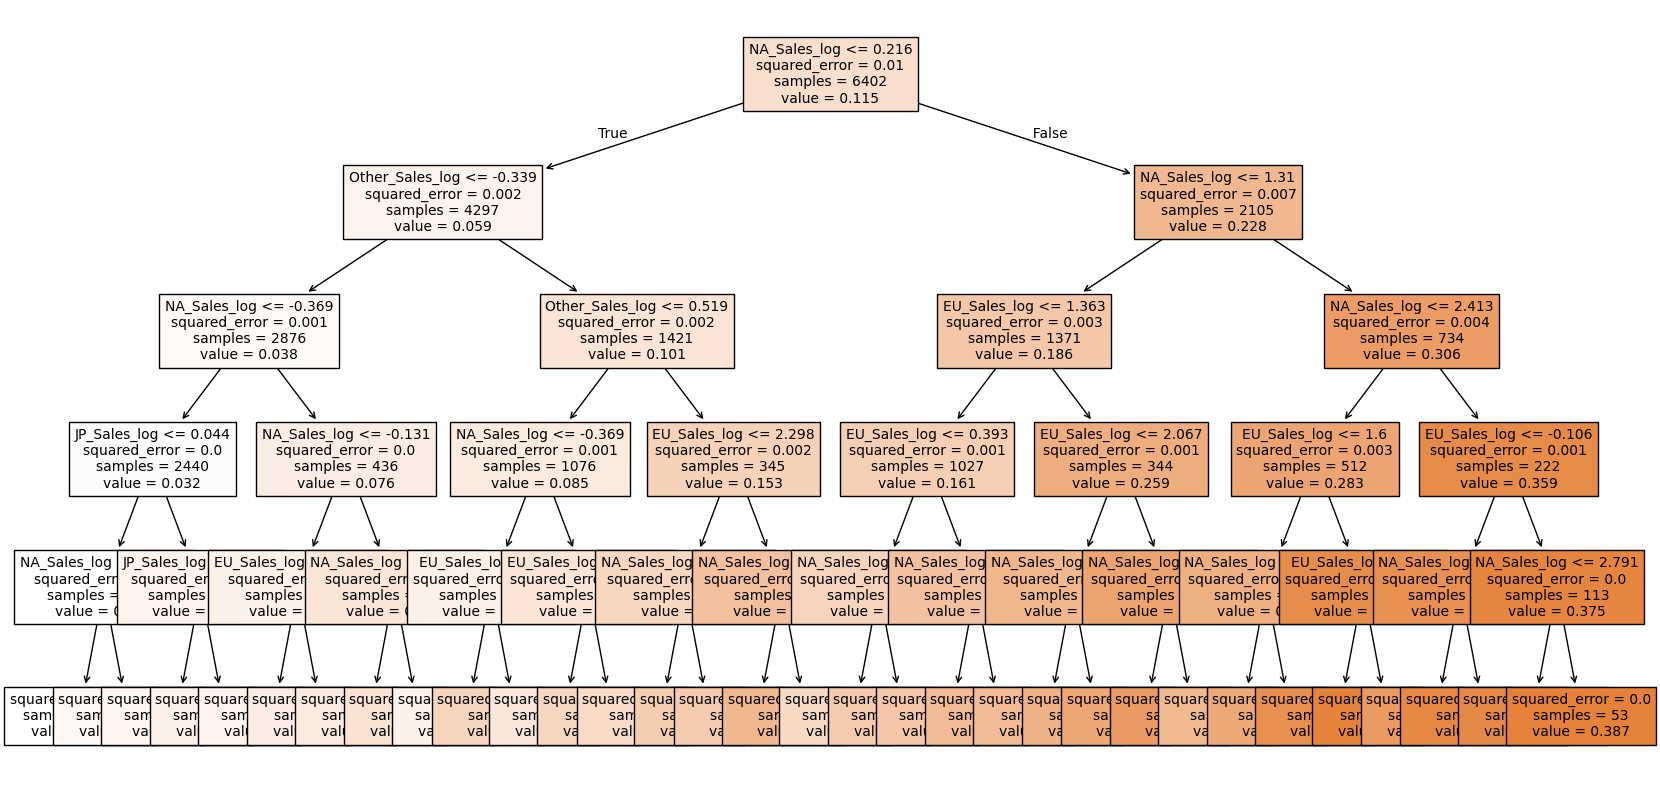

In [63]:
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns,
          #max_depth=3, # можем ораничить для наглядности
          filled=True, fontsize=10)
plt.show()

Без явных ограничений на глубину этот график плохо читается, но видно, что в основном преобладают признаки, связанные с продажами, причем NorthAmerica вообще стал корнем дерева, который далее также активно становится важным признаком для модели.

(Так же, можем построить и такое:

Визуализируем важность признака для алгоритма)

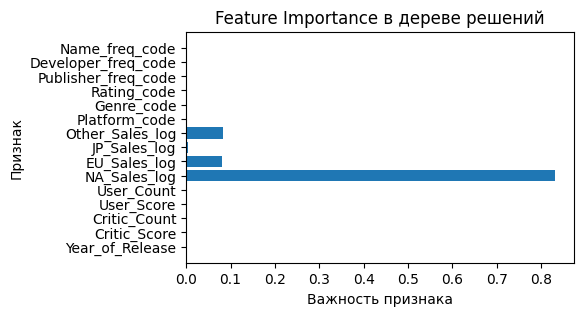

In [64]:
importances = dt.feature_importances_
features = X.columns

plt.figure(figsize=(5, 3))
plt.barh(features, importances)
plt.xlabel("Важность признака")
plt.ylabel("Признак")
plt.title("Feature Importance в дереве решений")
plt.show()

Тут уже явно выделяются продажи в северной америке.

### RF

Так как `RF` это ансамблевый метод, то есть сборка из множества решающих деревьев, то пострить график `tree_plot` мы можем либо для какого-то одного дерева из ансамбля, либо для нескольких.

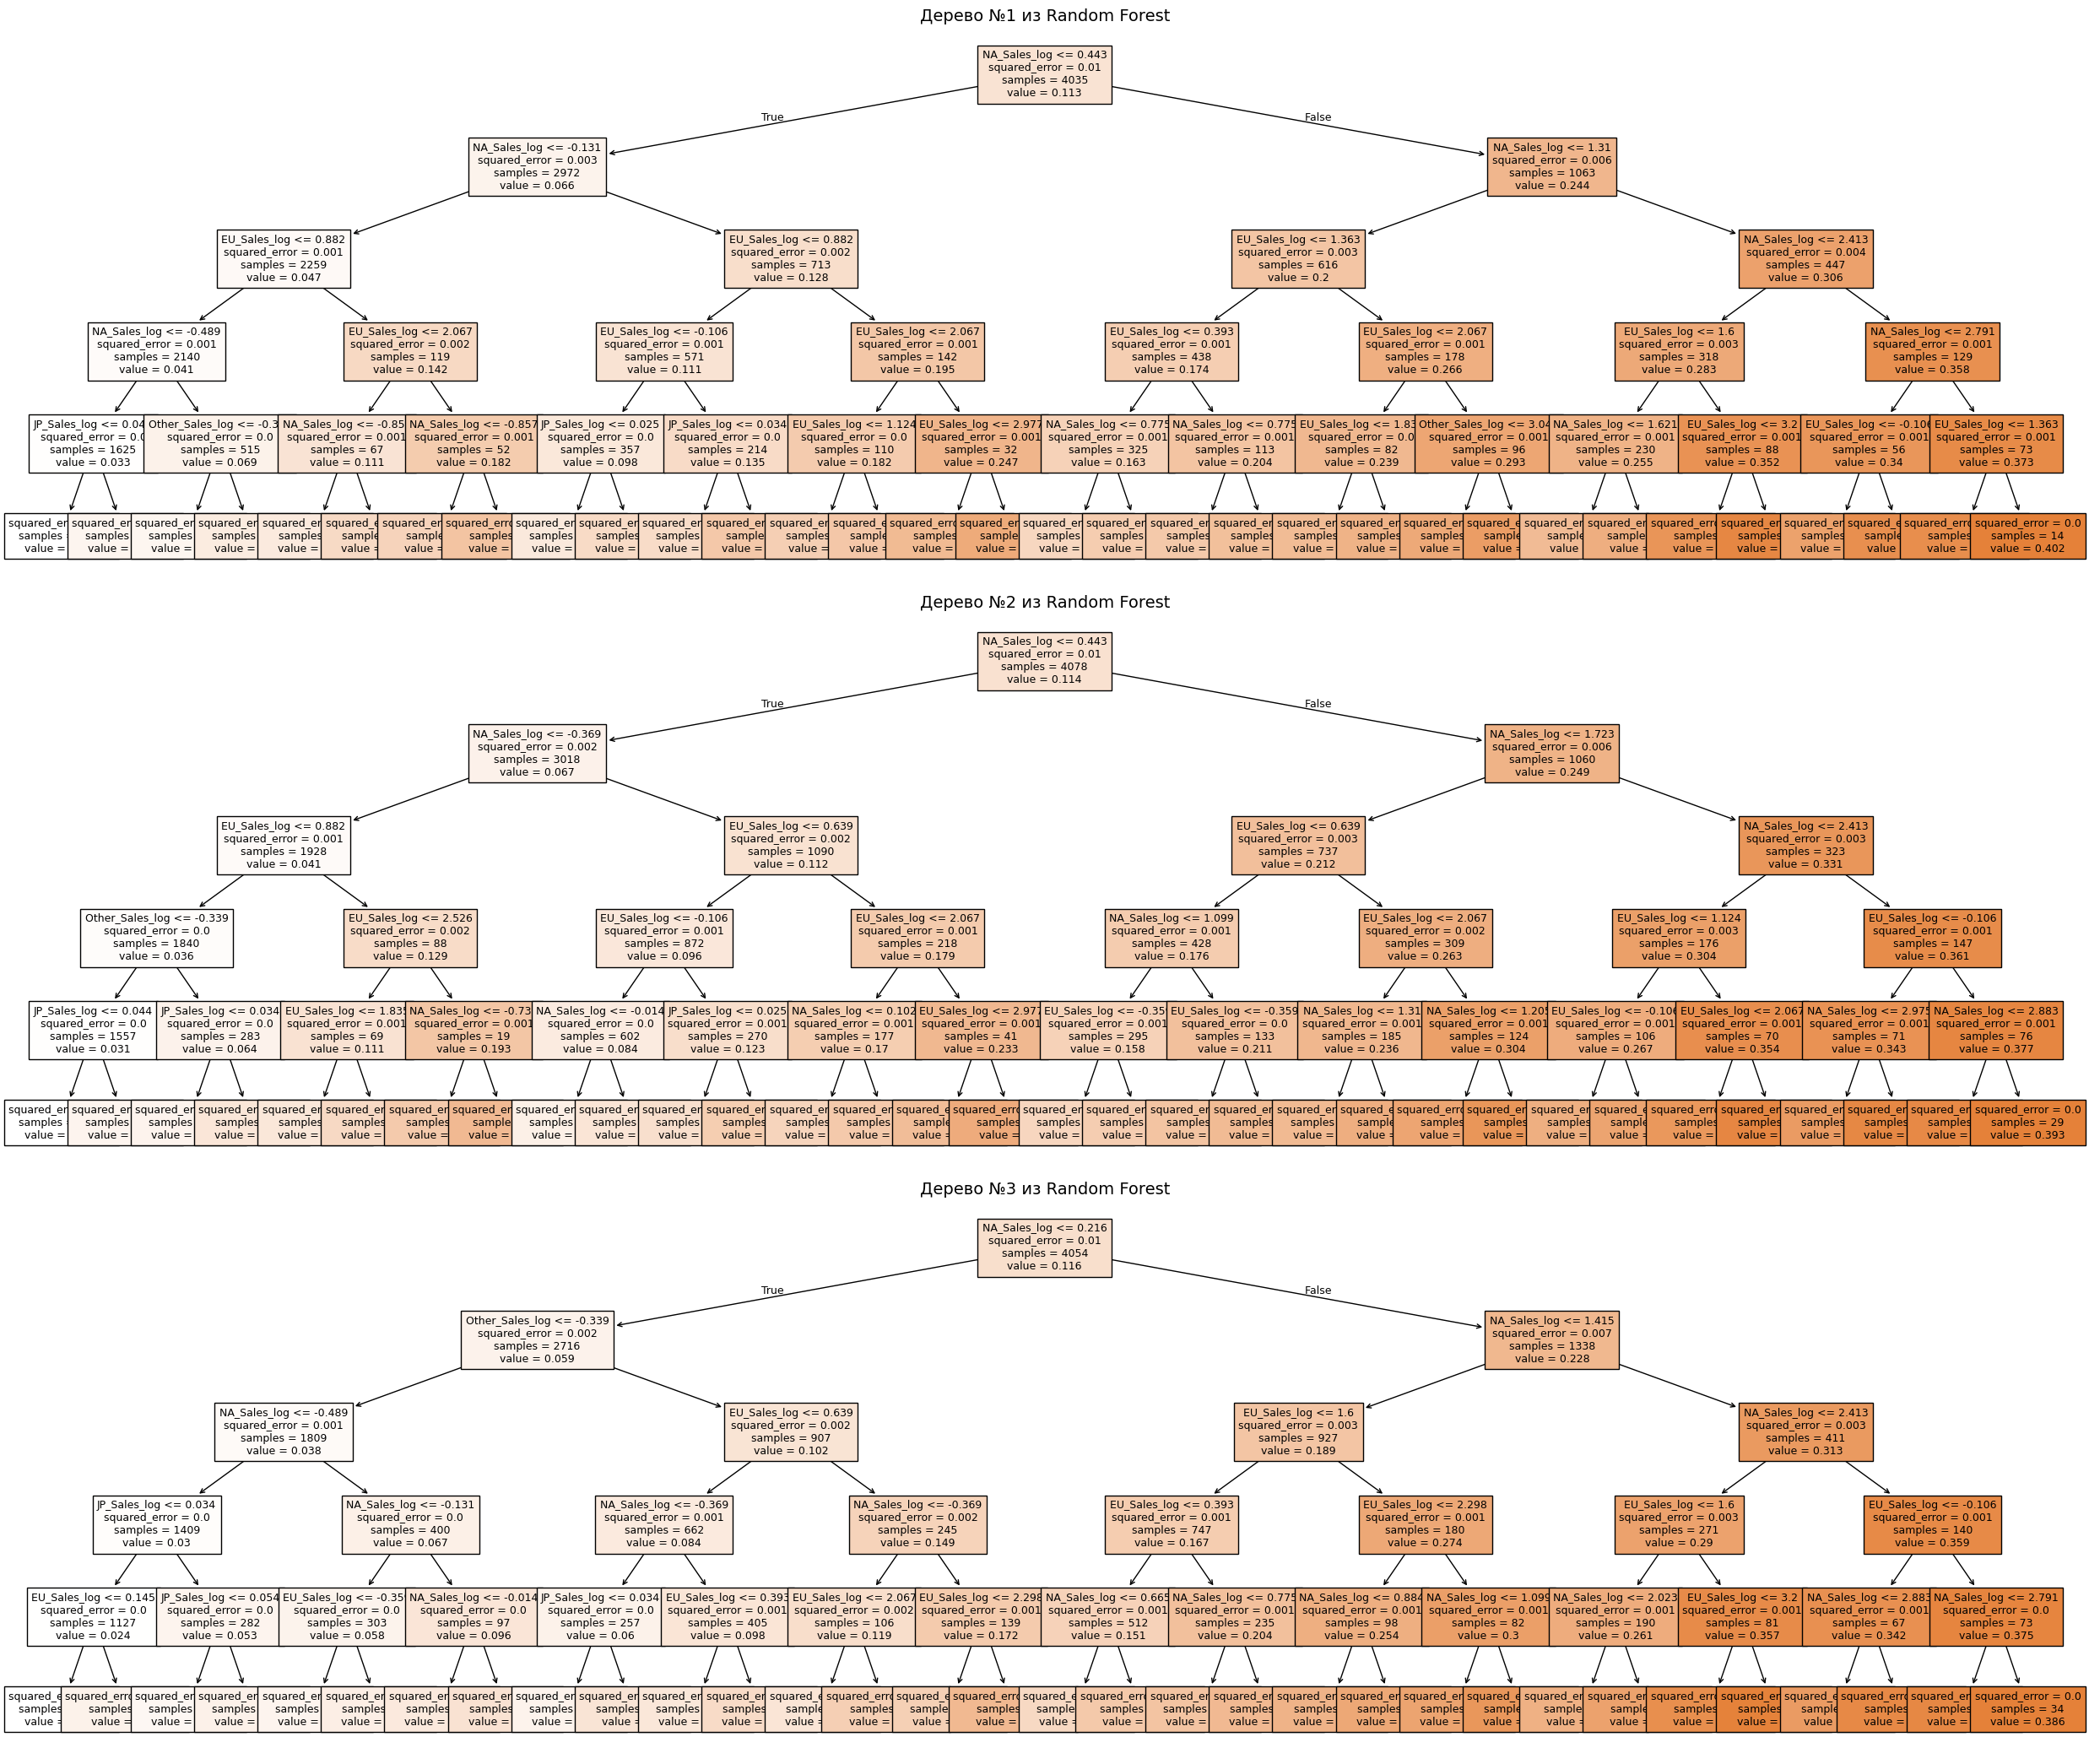

In [65]:
# Количество деревьев для отображения (всего было 100)
n_trees_to_plot = 3

# Индексы деревьев, которые хотим визуализировать
tree_indices = range(n_trees_to_plot)

plt.figure(figsize=(25, 7 * n_trees_to_plot))

for i, tree_idx in enumerate(tree_indices):
    plt.subplot(n_trees_to_plot, 1, i + 1)
    plot_tree(
        rf.estimators_[tree_idx],
        feature_names=X.columns,
        filled=True,
        #max_depth=3,    # Можем ограничить глубину визуализации для читаемости
        fontsize=9
    )
    plt.title(f"Дерево №{tree_idx + 1} из Random Forest", fontsize=14)

plt.tight_layout()
plt.show()

Визуализируем важность признака для алгоритма

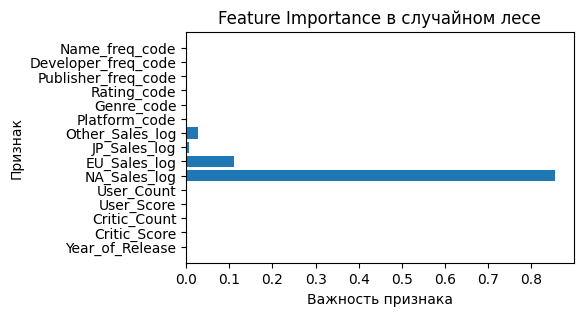

In [66]:
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(5, 3))
plt.barh(features, importances)
plt.xlabel("Важность признака")
plt.ylabel("Признак")
plt.title("Feature Importance в случайном лесе")
plt.show()

## Оптимизированные модели

По аналогии, построим графики для моделей с подобранными гиперпараметрами

### DT+Optuna

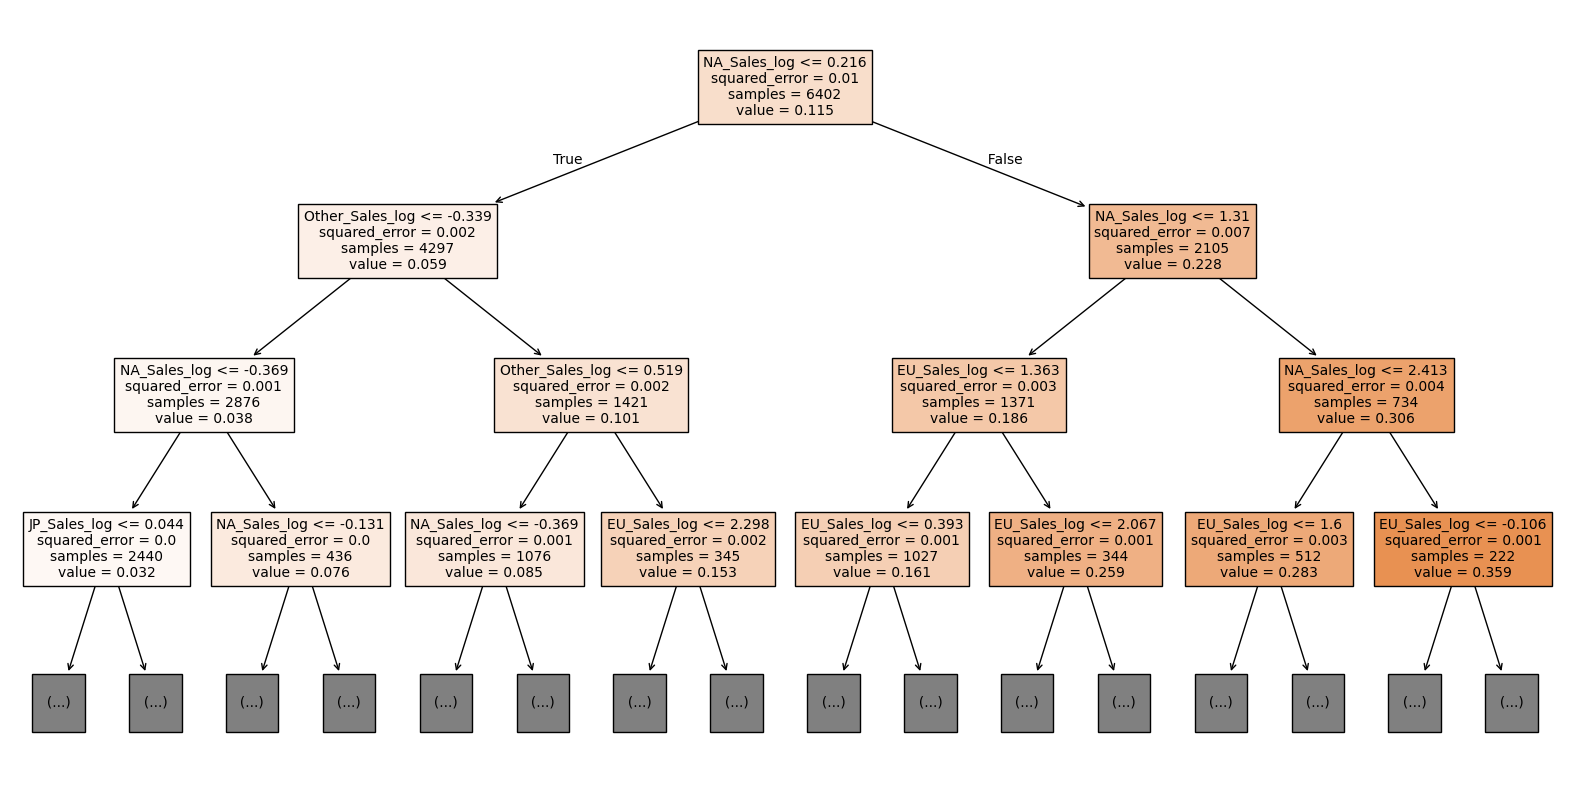

In [67]:
plt.figure(figsize=(20,10))
plot_tree(dt_opt, feature_names=X.columns, filled=True,
          max_depth=3, fontsize=10)
plt.show()

### RF+Optuna

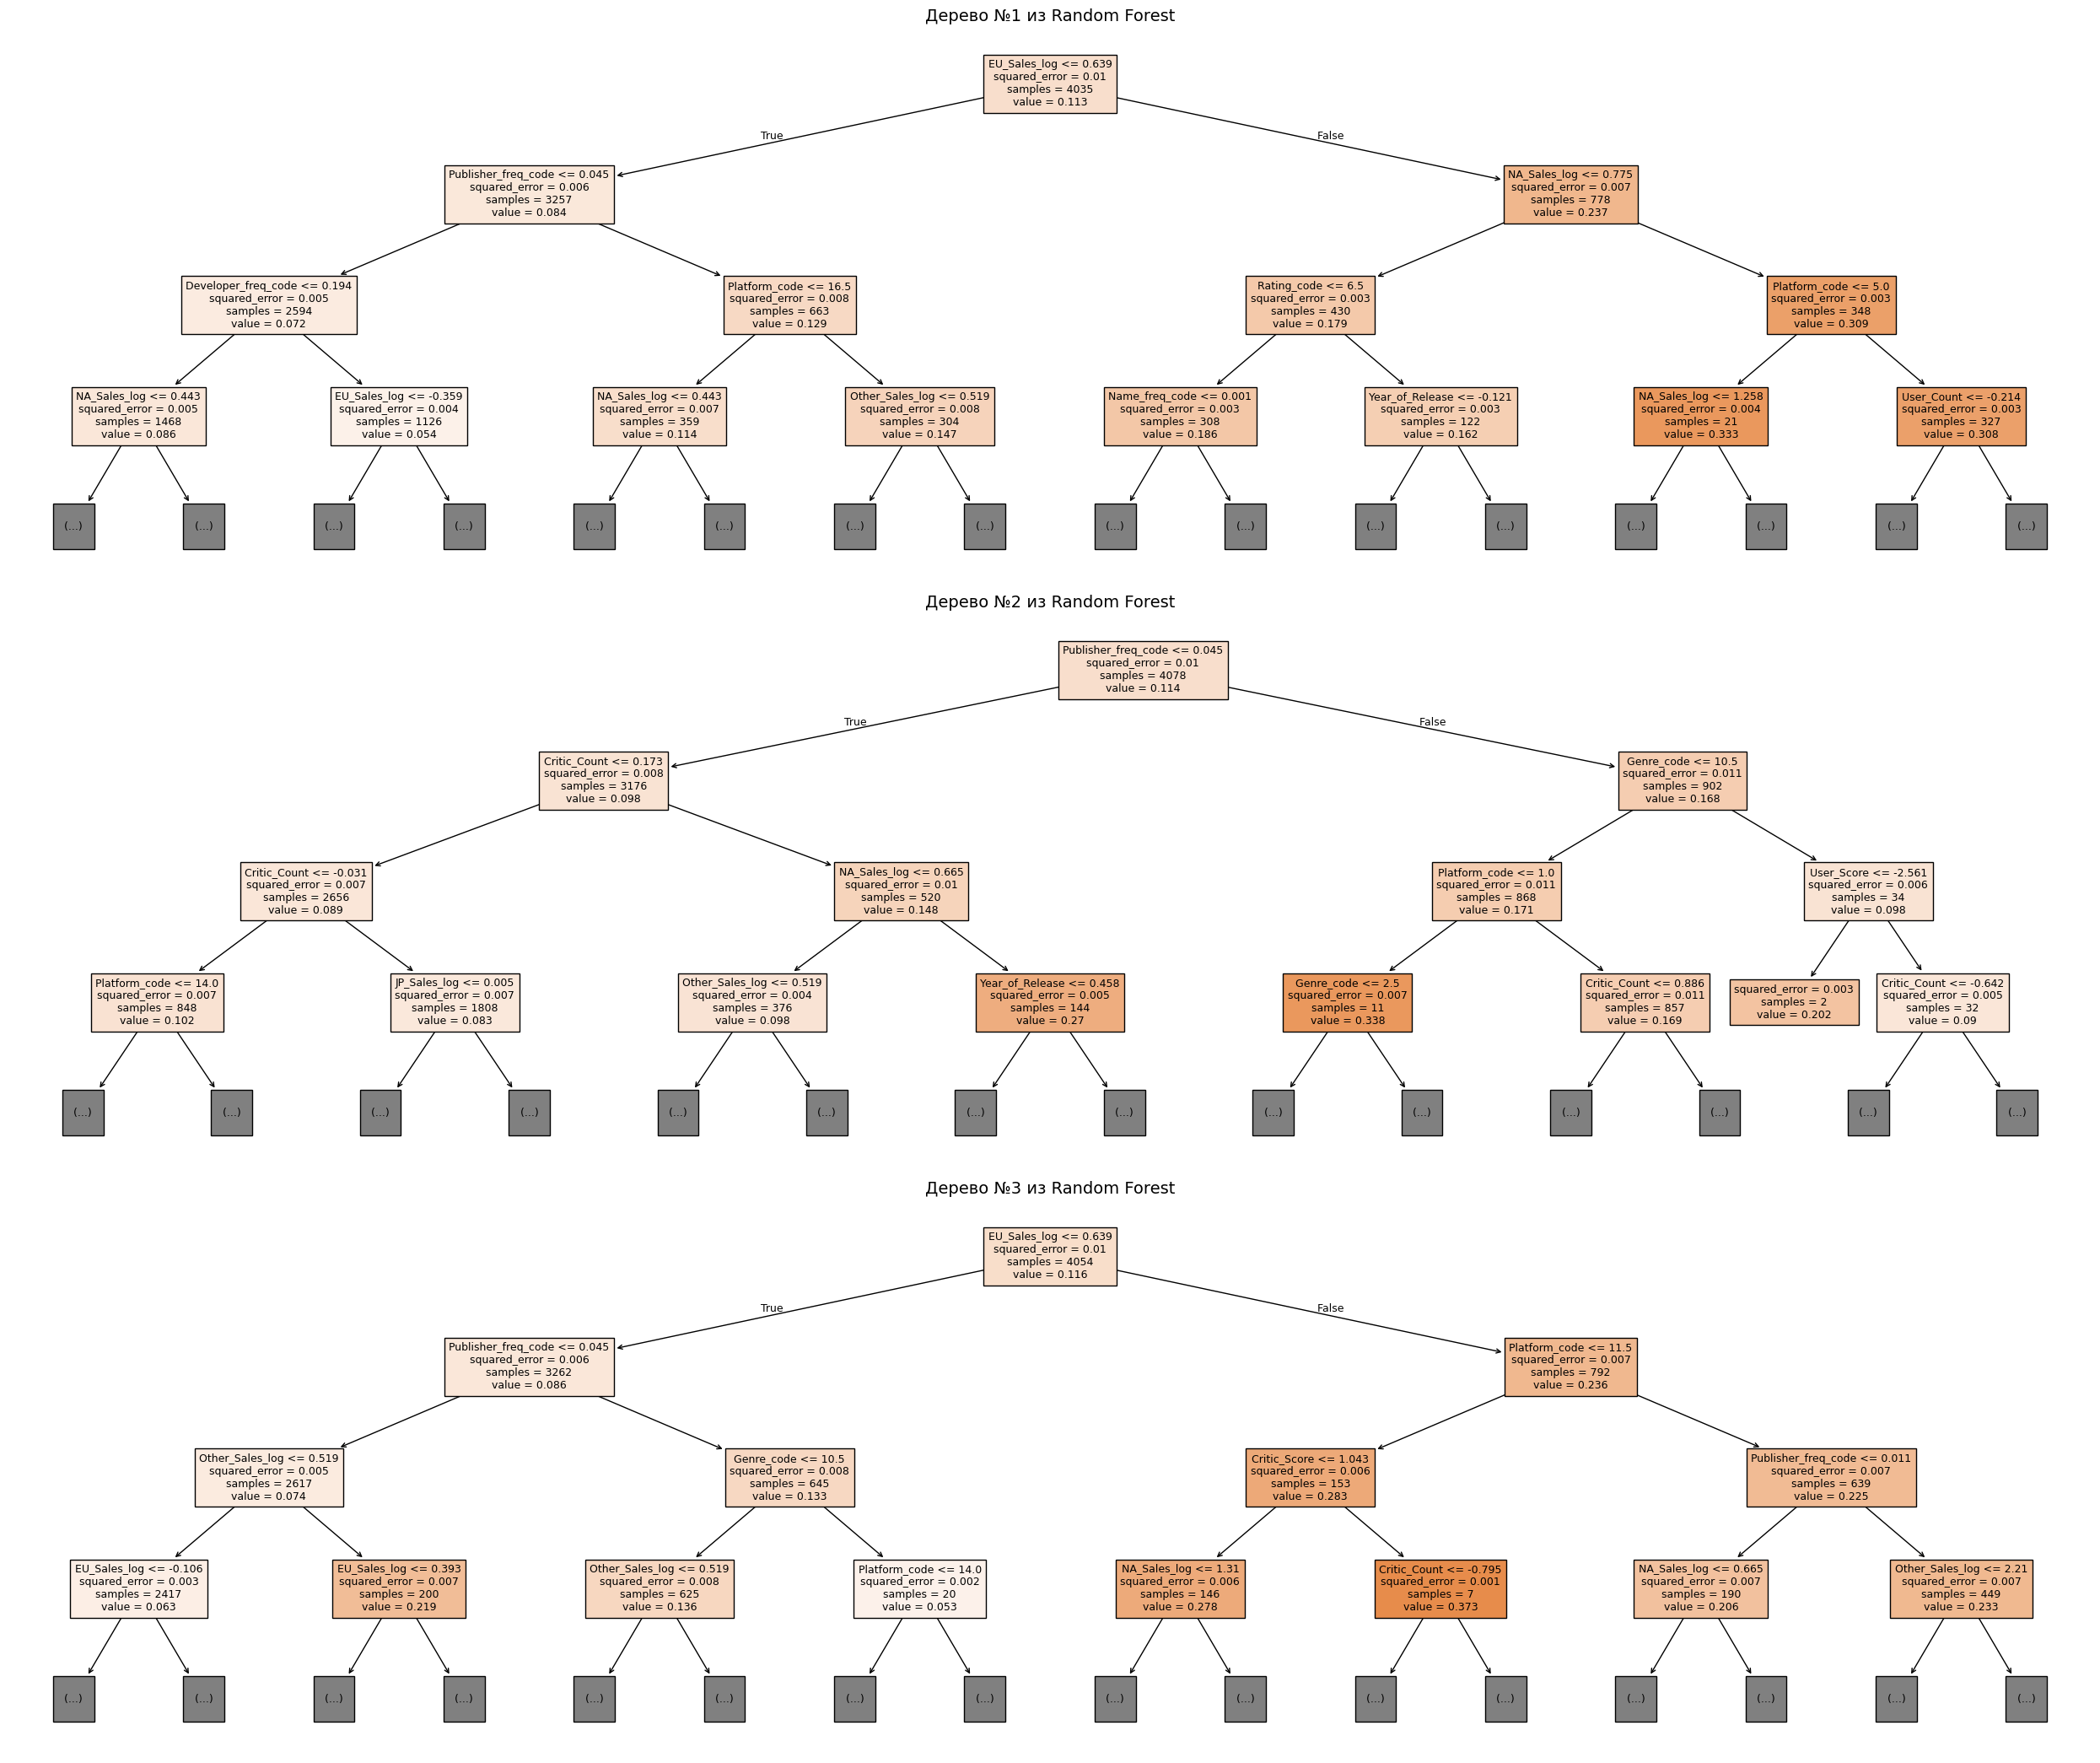

In [68]:
# Количество деревьев для отображения
n_trees_to_plot = 3

# Индексы деревьев, которые хотим визуализировать
tree_indices = range(n_trees_to_plot)

plt.figure(figsize=(25, 7 * n_trees_to_plot))

for i, tree_idx in enumerate(tree_indices):
    plt.subplot(n_trees_to_plot, 1, i + 1)
    plot_tree(
        rf_opt.estimators_[tree_idx],
        feature_names=X.columns,
        filled=True,
        max_depth=3,    # Можем ограничить глубину визуализации для читаемости
        fontsize=9
    )
    plt.title(f"Дерево №{tree_idx + 1} из Random Forest", fontsize=14)

plt.tight_layout()
plt.show()

## ➕9 Опционально: `GridSearch` (доп 2 балла)

### DT+GridSearch

In [69]:
# Модель
dt = DecisionTreeRegressor(random_state=42)

# Сетка гиперпараметров
param_grid_dt = {
    "max_depth": [1, 5, 7, 20, None],
    "min_samples_split": [2, 5, 20],
    "min_samples_leaf": [1, 2, 20],
    "criterion": ["squared_error"]
}

# Настройка Grid Search
grid_dt = GridSearchCV(
    dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Обучение
grid_dt.fit(X_train, y_train)

# Предсказания
y_pred_dt_grid = grid_dt.best_estimator_.predict(X_test)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


- Метрики

In [70]:
# Лучшие параметры и ошибка
print("Best parameters for Decision Tree:", grid_dt.best_params_)
print("Best RMSE:", (-grid_dt.best_score_)**0.5)

Best parameters for Decision Tree: {'criterion': 'squared_error', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 20}
Best RMSE: 0.009641062397267482


In [71]:
# Метрики для DT+GridSearch
mse_dt_gs = mean_squared_error(y_test, y_pred_dt_grid)
print(f"MSE (DT+GridSearch): {mse_dt_gs:.3f}")

rmse_dt_gs = np.sqrt(mean_squared_error(y_test, y_pred_dt_grid))
print(f"RMSE (DT+GridSearch): {rmse_dt_gs:.3f}")

r2_dt_gs = r2_score(y_test, y_pred_dt_grid)
print(f"R^2 (DT+GridSearch): {r2_dt_gs:.3f}")

mae_dt_gs = mean_absolute_error(y_test, y_pred_dt_grid)
print(f"MAE (DT+GridSearch): {mae_dt_gs:.3f}")

mape_dt_gs = np.mean(np.abs((y_test - y_pred_dt_grid) / y_test)) * 100
print(f"MAPE (DT+GridSearch): {mape_dt_gs:.2f}%")

MSE (DT+GridSearch): 0.000
RMSE (DT+GridSearch): 0.010
R^2 (DT+GridSearch): 0.991
MAE (DT+GridSearch): 0.006
MAPE (DT+GridSearch): 6.80%


###  RF+GridSearch

In [72]:
rf = RandomForestRegressor(random_state=42)

# Сетка гиперпараметров
param_grid_rf = {
    "n_estimators": [1, 10, 20],
    "max_depth": [1, 10, 20],
    "min_samples_split": [2, 5, 20],
    "min_samples_leaf": [1, 2, 20],
    "max_features": ["sqrt", "log2"]
}

# Настройка Grid Search
grid_rf = GridSearchCV(
    rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Обучение
grid_rf.fit(X_train, y_train)

# Предсказания
y_pred_rf_grid = grid_rf.best_estimator_.predict(X_test)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


- Метрики

In [73]:
# Лучшие параметры и ошибка
print("Best parameters for Random Forest:", grid_rf.best_params_)
print("Best RMSE:", (-grid_rf.best_score_)**0.5)

Best parameters for Random Forest: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 20}
Best RMSE: 0.014064280519461594


In [74]:
# Метрики для RF+GridSearch
mse_rf_gs = mean_squared_error(y_test, y_pred_rf_grid)
print(f"MSE (RF+GridSearch): {mse_rf_gs:.3f}")

rmse_rf_gs = np.sqrt(mean_squared_error(y_test, y_pred_rf_grid))
print(f"RMSE (RF+GridSearch): {rmse_rf_gs:.3f}")

r2_rf_gs = r2_score(y_test, y_pred_rf_grid)
print(f"R^2 (RF+GridSearch): {r2_rf_gs:.3f}")

mae_rf_gs = mean_absolute_error(y_test, y_pred_rf_grid)
print(f"MAE (RF+GridSearch): {mae_rf_gs:.3f}")

mape_rf_gs = np.mean(np.abs((y_test - y_pred_rf_grid) / y_test)) * 100
print(f"MAPE (RF+GridSearch): {mape_rf_gs:.2f}%")

MSE (RF+GridSearch): 0.000
RMSE (RF+GridSearch): 0.014
R^2 (RF+GridSearch): 0.982
MAE (RF+GridSearch): 0.009
MAPE (RF+GridSearch): 13.39%


## ➕ 8 & 9 Сравнение результатов алгоритмов между собой, без и с `Optuna`, без и с `GridSearch`

Напомним, в ходе работы алгоритмы имели следующие значения метрик:

In [75]:
data = {
    "RMSE": [rmse_dt, rmse_dt_opt, rmse_dt_gs],
    "MSE": [mse_dt, mse_dt_opt, mse_dt_gs],
    "R^2": [r2_dt, r2_dt_opt, r2_dt_gs],
    "MAE": [mae_dt, mae_dt_opt, mae_dt_gs],
    "MAPE (%)": [mape_dt, mape_dt_opt, mape_dt_gs],
}

df_dt_metrics = pd.DataFrame(data, index=["DT", "DT + Optuna", "DT + GridSearch"])
print("Метрики моделей Decision Tree:")
display(df_dt_metrics.round(3))

Метрики моделей Decision Tree:


,RMSE,MSE,R^2,MAE,MAPE (%)
DT,0.019,0.0,0.966,0.013,22.321
DT + Optuna,0.009,0.0,0.992,0.005,6.693
DT + GridSearch,0.010,0.0,0.991,0.006,6.804


In [76]:
data = {
    "RMSE": [rmse_rf, rmse_rf_opt, rmse_rf_gs],
    "MSE": [mse_rf, mse_rf_opt, mse_rf_gs],
    "R^2": [r2_rf, r2_rf_opt, r2_rf_gs],
    "MAE": [mae_rf, mae_rf_opt, mae_rf_gs],
    "MAPE (%)": [mape_rf, mape_rf_opt, mape_rf_gs],
}

df_rf_metrics = pd.DataFrame(data, index=["RF", "RF + Optuna", "RF + GridSearch"])
print("Метрики моделей Random Forest:")
display(df_rf_metrics.round(3))

Метрики моделей Random Forest:


,RMSE,MSE,R^2,MAE,MAPE (%)
RF,0.014,0.0,0.982,0.010,21.854
RF + Optuna,0.015,0.0,0.979,0.009,13.965
RF + GridSearch,0.014,0.0,0.982,0.009,13.387


### **Сравнение:**

1. Между собой:
- лучшие показатели в целом показывает *случайный лес*, оно обосновывается в первую очередь своим построением.

2. Без и с Optuna:
- Для дерева решений применение Optunы ощутимо *повысило* качество.
- Для случайного леса значительно *понизилась MAPE*.

(Надо упомянуть, что само варьирование в целом было несколько ограниченно, похожие и у DT и у RF. Расширив область можно было бы достигнуть лучшего, но, кажется и при таком варьировании модель славно переобучается)

3. (ДОП) Без и с GridSearch:
- После применения GridSearch точность обеих моделей выросла, однако *DT+GridSearch показала лучшее качество* по сравнению с *RF+GridSearch*, что указывает на её более точное соответствие данным после подбора гиперпараметров.


Optuna и GridSearch:

*Для DF лучше показала себя Optuna, на RF, напротив,GridSearch.* Оба раза эта разница измерялась тысячными долями в большинстве метрик, что в целом -- не столь весомо.




Говоря о *скорости обучения*, не трудно заметить, что более крупные ансамблевые модели обучаились дольше, чем одно регрессионное дерево. Скорость подбора гиперпараметров так же связана с этим фактом.

В целом, важность подбора гиперпараметров подтверждается: использование Optuna и GridSearch помогает автоматизировать этот процесс и получить, вследствии, лучшие результаты.
Однако, стоит заметить, что грубое задание сетки в последнем несколько ограничивает его возможности.